# Kalman Filter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import seaborn as sns

In [2]:
def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with DateTimeIndex.
    Each DataFrame is plotted as a separate line with the same style but different colors_line.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have DateTimeIndex)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have DateTimeIndex
    for i, df in enumerate(dfs):
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"DataFrame {i} must have a DateTimeIndex")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy().sort_index()

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot.loc[start_date:end_date]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label, color_line, color_scatter) in enumerate(zip(dfs_plot, labels, colors_line, colors_scatter)):
        if len(df_plot) == 0:
            continue

        # Plot types - all DataFrames use same style but different colors_line
        if plot_type == 'line':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            df_resampled = df_plot[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if not isinstance(filled_df.index, pd.DatetimeIndex):
            raise ValueError("filled_df must also have a DateTimeIndex")
        filled_copy = filled_df.copy().sort_index()

        # Find timestamps in filled_df but missing in original df
        new_times = filled_copy.index.difference(dfs[0].index)

        if not new_times.empty:
            filled_only = filled_copy.loc[new_times]
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only.loc[start_date:end_date]

            if not filled_only.empty:
                ax.scatter(filled_only.index, filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig

# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


In [3]:
graph2 = pd.read_csv('data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
def index_dataset(df, time_column):
    df[time_column] = pd.to_datetime(df[time_column])
    df.sort_values(time_column, inplace=True)
    df.set_index(time_column, inplace=True)
        
index_dataset(graph2, "Time of reading")
graph2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17267 entries, 2024-08-29 00:14:56 to 2025-08-29 17:06:45
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VAR_ID  17267 non-null  int64  
 1   Value   17267 non-null  float64
 2   Diff.   17266 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 539.6 KB


In [4]:
graph2["Diff."].isnull().values.sum()

1

In [5]:
graph2[graph2.isna().any(axis=1)]

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:14:56,55419,789.73,NaN


In [6]:
graph2 = graph2.dropna()
graph2.head()

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:44:56,55419,789.73,0.0
2024-08-29 01:14:56,55419,789.73,0.0
2024-08-29 01:44:56,55419,789.73,0.0
2024-08-29 02:14:56,55419,789.73,0.0
2024-08-29 02:44:56,55419,789.73,0.0


In [ ]:
graph2_resampled = graph2.resample('30T').asfreq()
graph2_resampled["Diff."].isnull().values.sum()

C:\Users\Ondřej Černý\AppData\Local\Temp\ipykernel_16868\3752365018.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  graph2_resampled = graph2.resample('30T').asfreq()


,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:44:56,55419,789.73,0.0
2024-08-29 01:14:56,55419,789.73,0.0
2024-08-29 01:44:56,55419,789.73,0.0
2024-08-29 02:14:56,55419,789.73,0.0
2024-08-29 02:44:56,55419,789.73,0.0


In [7]:
class KalmanFilterRandomWalk:
    def __init__(self, Q=1e-5, R=1e-5):
        # State transition matrix
        self.A = np.array([[1]])
        # Observation matrix
        self.H = np.array([[1]])
        # Process noise covariance
        self.Q = np.array([[Q]])
        # Measurement noise covariance
        self.R = np.array([[R]])
        # Initial state estimate
        self.x_hat = None
        # Initial covariance estimate
        self.P = None
        
    def initialize(self, initial_state=0, initial_covariance=1):
        self.x_hat = np.array([[initial_state]])
        self.P = np.array([[initial_covariance]])
        
    def predict(self):
        # Predict the next state
        self.x_hat = self.A @ self.x_hat
        self.P = self.A @ self.P @ self.A.T + self.Q
        
    def update(self, measurement):
        # Innovation
        y_tilde = measurement - (self.H @ self.x_hat)
        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.R
        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)
        # Update state estimate
        self.x_hat = self.x_hat + K @ y_tilde
        # Update covariance estimate
        self.P = (np.eye(self.P.shape[0]) - K @ self.H) @ self.P
        return y_tilde, S  # Return innovation and its covariance

def run_kalman_filter_on_diff(df, Q=1e-5, R=1e-5):
    """
    Runs Kalman filter on Diff. values of DataFrame df.
    Assumes df.index is the time of reading and df['Diff'] contains Diff. values.
    
    Returns:
    - df_results: original df with added columns for state estimate, innovation, and innovation magnitude
    """
    kf = KalmanFilterRandomWalk(Q=Q, R=R)
    kf.initialize(initial_state=0, initial_covariance=1)
    
    state_estimates = []
    innovation_vals = []
    innovation_magnitudes = []
    
    for diff_val in df['Diff.']:
        kf.predict()
        innovation, S = kf.update(np.array([[diff_val]]))
        state_estimates.append(kf.x_hat.item())
        innovation_vals.append(innovation.item())
        innovation_magnitudes.append(np.sqrt(innovation.T @ np.linalg.inv(S) @ innovation).item())
    
    df_results = df.copy()
    df_results['Diff.'] = state_estimates
    df_results['Innovation'] = innovation_vals
    df_results['Innovation_Magnitude'] = innovation_magnitudes
    
    return df_results

# Example usage:
# df is your DataFrame with DateTime index and 'Diff' column
df_filtered = run_kalman_filter_on_diff(graph2, Q=1e-5, R=1e-5)
# You can then analyze df_filtered['Innovation_Magnitude'] for anomalies.


In [8]:
df_filtered.head()

,VAR_ID,Value,Diff.,Innovation,Innovation_Magnitude
Time of reading,,,,,
2024-08-29 00:44:56,55419,789.73,0.0,0.0,0.0
2024-08-29 01:14:56,55419,789.73,0.0,0.0,0.0
2024-08-29 01:44:56,55419,789.73,0.0,0.0,0.0
2024-08-29 02:14:56,55419,789.73,0.0,0.0,0.0
2024-08-29 02:44:56,55419,789.73,0.0,0.0,0.0


DataFrame 1 (DF1): 96 points
DataFrame 2 (DF2): 96 points
Filtered to date range: 192 total points


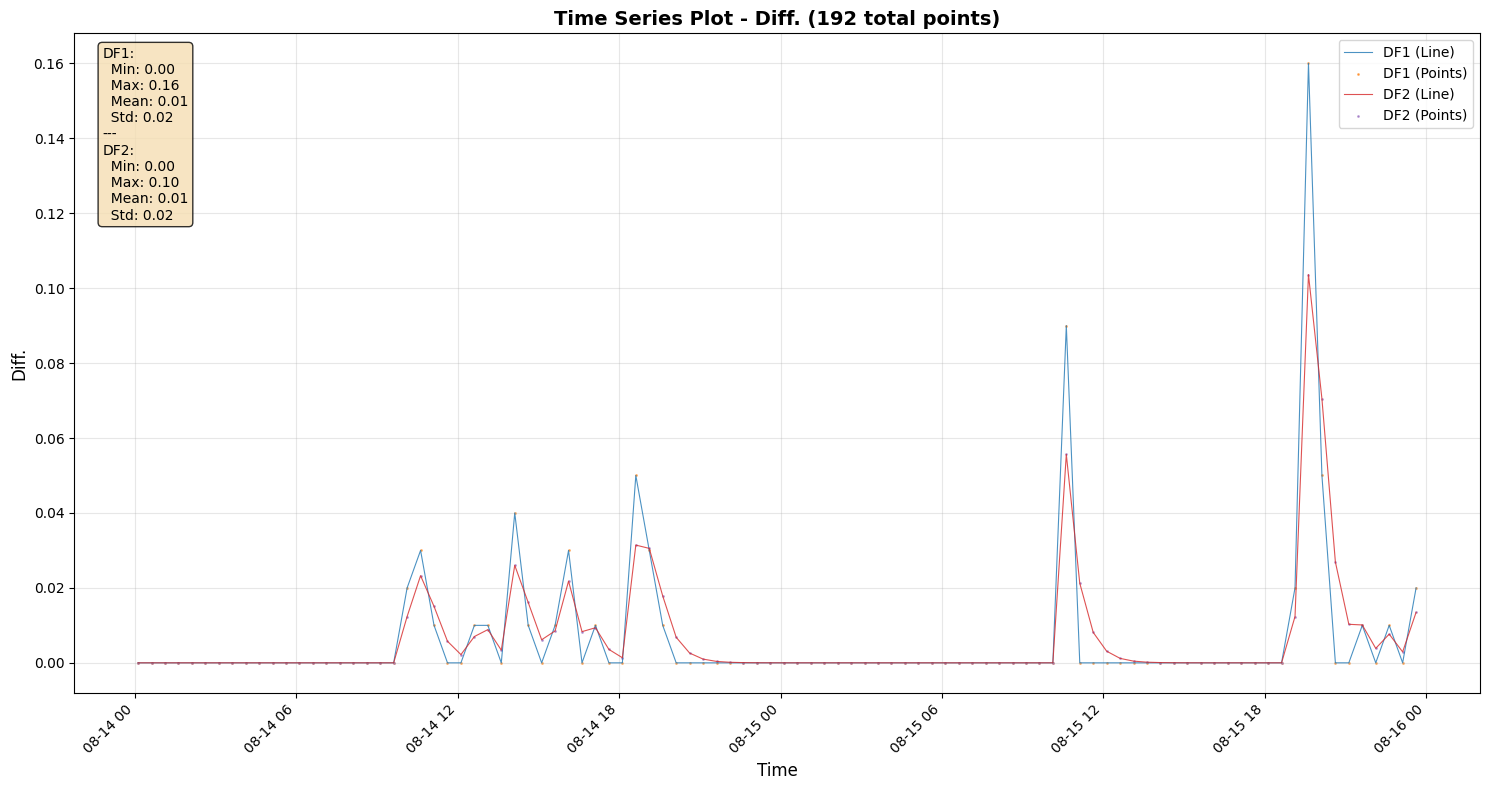

In [9]:
plot_timeseries([graph2, df_filtered], value_column="Diff.", date_range=("2025-08-14", "2025-08-15"), plot_type="both")

## Seasonal KF

Structural models, statsmodels. Sarimax

In [10]:
from kfs import run_em_kalman_filter

In [11]:
graph2.rename(columns={'Diff.': 'Diff'}, inplace=True)

In [12]:
df_results, model = run_em_kalman_filter(graph2)

Training EM Kalman Filter on 500 samples...
EM converged: False after 20 iterations


TypeError: unsupported format string passed to numpy.ndarray.__format__